<a href="https://colab.research.google.com/github/Innovatewithapple/NeuralNetwork/blob/main/NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Data --------------------
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T   # shape (2,4)
d = np.array([[0, 1, 1, 0]])                       # shape (1,4)

# -------------------- Initialize --------------------
def initialize_network_parameters():
    inputSize = 2
    hiddenSize = 2
    outputSize = 1
    lr = 0.1
    epochs = 10000

    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1

    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1
    b2 = np.random.rand(outputSize, 1) * 2 - 1

    return w1, b1, w2, b2, lr, epochs

# -------------------- Sigmoid --------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -------------------- Initialize params --------------------
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# -------------------- Training --------------------
error_list = []

for epoch in range(epochs):

    # -------- Forward pass --------
    z1 = np.dot(w1, X) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(w2, a1) + b2
    a2 = sigmoid(z2)

    # -------- Loss (for monitoring only) --------
    loss = -np.mean(d * np.log(a2 + 1e-8) + (1 - d) * np.log(1 - a2 + 1e-8))

    # -------- Backpropagation --------

    # Output layer (MODERN)
    dz2 = a2 - d
    dw2 = np.dot(dz2, a1.T)
    db2 = np.sum(dz2, axis=1, keepdims=True)

    # Hidden layer
    da1 = np.dot(w2.T, dz2)
    dz1 = da1 * (a1 * (1 - a1))
    dw1 = np.dot(dz1, X.T)
    db1 = np.sum(dz1, axis=1, keepdims=True)

    # -------- Update --------
    w2 -= lr * dw2
    b2 -= lr * db2

    w1 -= lr * dw1
    b1 -= lr * db1

    # -------- Logging --------
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.5f}")
        error_list.append(loss)

# -------------------- Testing --------------------
z1 = np.dot(w1, X) + b1
a1 = sigmoid(z1)

z2 = np.dot(w2, a1) + b2
a2 = sigmoid(z2)

print("\nFinal Output:")
print(a2)

print("\nGround Truth:")
print(d)

# -------------------- Plot --------------------
plt.plot(error_list)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
x_1 = 0.1
x_2 = 0.8
w_1 = 0.5
w_2 = 0.4
b_1 = 0.3

In [24]:
z = x_1*w_1+x_2*w_2+b_1
z

0.67

In [25]:
#Sigmoid
a_1 = 1/(1.0 + np.exp(-z))
a_1

np.float64(0.6615031592029524)

In [26]:
# Another
weights = np.around(np.random.uniform(size=6),decimals=2)

bias = np.around(np.random.uniform(size=3),decimals=2)

In [27]:
bias

array([0.78, 0.8 , 0.61])

In [28]:
weights

array([0.62, 0.96, 0.61, 0.12, 0.15, 0.03])

In [29]:
x_1 = 0.5 # input 1
x_2 = 0.85 # input 2

In [30]:
z_11 = x_1 * weights[0] + x_2 * weights[1] + bias[0]
print(z_11)

1.906


In [31]:
z_12 = x_1 * weights[2] + x_2 * weights[3] + bias[1]
print(z_12)

1.207


In [32]:
# Perform Sigmoid
a_11 = 1 / (1.0 + np.exp(-z_11))
print(a_11)

0.87056910138269


In [33]:
a_12 = 1 / (1.0 + np.exp(-z_12))
print(a_12)

0.7697677032250415


In [34]:
z_21 = a_11 * weights[4] + a_12 * weights[5] + bias[2]
print(z_21)

0.7636783963041547


In [35]:
a_21 = 1 / (1.0 + np.exp(-z_21))

In [36]:
print(a_21)

0.6821518201427971


Activation function with loss function

In [37]:
# Sigmoid-Activation
# 1/(1-e^-z)
zArr = [-1, 0, 1]
TArr = [0, 1, 1]   # targets

for z, T in zip(zArr, TArr):
    a = 1/(1+np.exp(-z))
    # Sigmoid-
    # Loss = -[T*log(a) + (1-T)*log(1-a)]
    loss = -(T*np.log(a) + (1-T)*np.log(1-a))

    print("z:", z, "a:", round(a,3), "Loss:", round(loss,3))

z: -1 a: 0.269 Loss: 0.313
z: 0 a: 0.5 Loss: 0.693
z: 1 a: 0.731 Loss: 0.313


In [78]:
X = np.array([[0,0],[0,1],[1,0],[1,1]]).T
d = np.array([[0,1,1,0]])
X
d

array([[0, 1, 1, 0]])

In [39]:
a = np.random.rand(2,3)
a

array([[0.97067252, 0.02125037, 0.28034287],
       [0.36977127, 0.99463918, 0.74469976]])

In [119]:
def initialize_parameters(layers):
    weights = []
    biases = []
    lr = 0.1
    epochs = 180000

    for i in range(len(layers)-1):
        #print('i:',i)
        w = np.random.rand(layers[i+1], layers[i]) * 2 - 1
        b = np.random.rand(layers[i+1], 1) * 2 - 1
        #print('w:',w)
        weights.append(w)
        biases.append(b)

    return weights, biases, lr, epochs, layers[0],layers[-1]

layers = [2, 2, 1]

weights, biases, lr, epochs, input, output = initialize_parameters(layers)
weights[1].T

array([[ 0.1676],
       [-0.462 ]])

In [108]:
biases

[array([[-0.36048223],
        [-0.88583947]]),
 array([[-0.63440053]])]

In [120]:
#Sigmoid function
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [128]:
errorlist = []

for epoch in range(epochs):
  z1 = np.dot(weights[0],X) + biases[0]# from input to hidden layer
  a1 = sigmoid(z1) # sigmoid of hidden layer first neuron

  z2 = np.dot(weights[1],a1) + biases[1]# from hidden layer to output
  a2 = sigmoid(z2)
 # print('a2: ',a2)
  #lossa
  loss = -np.mean(d * np.log(a2 + 1e-8) + (1 - d) * np.log(1 - a2 + 1e-8))
 # print('loss: ',loss)

  #Backward propogation-Output layer:
  dz2 = a2-d
  dzW2 = np.dot(dz2,a1.T)
  dzB2 = np.sum(dz2,axis=1,keepdims=True)

  #Backward propogation-Hidden layer:
  # print('a1',a2.shape)
  # print('shape of dz2',dz2.shape)
  # print('shape of weights',weights[1].shape)
  da1 = np.dot(weights[1].T,dz2)
  dz1 = da1 * (a1 * (1 - a1))
  dzW1 = np.dot(dz1,X.T)
  dzB1 = np.sum(dz1,axis=1,keepdims=True)

  # print('dzW2: ',dzW2)
  # print('dzB2: ',dzB2)

  # print('dzW1: ',dzW1)
  # print('dzB1: ',dzB1)

# update weight & bias
  weights[1] -= lr * dzW2
  biases[1] -= lr * dzB2

  weights[0] -= lr * dzW1
  biases[0] -= lr * dzB1

# -------- Logging --------
  if (epoch + 1) % 10000 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.5f}")
        print("mean |dz1|:", np.mean(np.abs(dz1)))
        errorlist.append(loss)

      #   ❌ BAD VANISHING EXAMPLE (LIKE YOUR LOG)
      #  Epoch 1000, Loss: 0.69
      #  mean |dz1|: 1.2e-05

      #  Epoch 5000, Loss: 0.69
      #  mean |dz1|: 9.8e-06

      #  Epoch 10000, Loss: 0.69
      #  mean |dz1|: 8.5e-06


Epoch 10000, Loss: 0.00004
mean |dz1|: 1.0184603981012254e-05
Epoch 20000, Loss: 0.00004
mean |dz1|: 9.987943936974506e-06
Epoch 30000, Loss: 0.00004
mean |dz1|: 9.798488085807904e-06
Epoch 40000, Loss: 0.00004
mean |dz1|: 9.615852322702898e-06
Epoch 50000, Loss: 0.00004
mean |dz1|: 9.43967920683741e-06
Epoch 60000, Loss: 0.00004
mean |dz1|: 9.26963569560145e-06
Epoch 70000, Loss: 0.00004
mean |dz1|: 9.105411105476914e-06
Epoch 80000, Loss: 0.00004
mean |dz1|: 8.946715273496198e-06
Epoch 90000, Loss: 0.00004
mean |dz1|: 8.793276896914714e-06
Epoch 100000, Loss: 0.00004
mean |dz1|: 8.644842030807529e-06
Epoch 110000, Loss: 0.00004
mean |dz1|: 8.501172727048209e-06
Epoch 120000, Loss: 0.00003
mean |dz1|: 8.362045798692577e-06
Epoch 130000, Loss: 0.00003
mean |dz1|: 8.22725169712316e-06
Epoch 140000, Loss: 0.00003
mean |dz1|: 8.096593489857687e-06
Epoch 150000, Loss: 0.00003
mean |dz1|: 7.969885928490217e-06
Epoch 160000, Loss: 0.00003
mean |dz1|: 7.846954598248705e-06
Epoch 170000, Loss:

In [123]:
np.set_printoptions(suppress=True, precision=4)

In [124]:
z1 = np.dot(weights[0],X) + biases[0]
a1 = sigmoid(z1)

z2 = np.dot(weights[1],a1) + biases[1]
a2 = sigmoid(z2)

print("\nFinal Output:")
print(a2)

print("\nGround Truth:")
print(d)


Final Output:
[[0.0001 0.9999 0.9999 0.0001]]

Ground Truth:
[[0 1 1 0]]


In [125]:
# Step 1: Prediction
pred = (a2 > 0.5).astype(int)

# Step 2: Accuracy
accuracy = np.mean(pred == d)

# Step 3: Print everything
print("Probabilities:", a2)
print("Predictions:", pred)
print("Actual:", d)
print("Accuracy:", accuracy * 100, "%")
print("Errors per sample:", pred - d)

Probabilities: [[0.0001 0.9999 0.9999 0.0001]]
Predictions: [[0 1 1 0]]
Actual: [[0 1 1 0]]
Accuracy: 100.0 %
Errors per sample: [[0 0 0 0]]


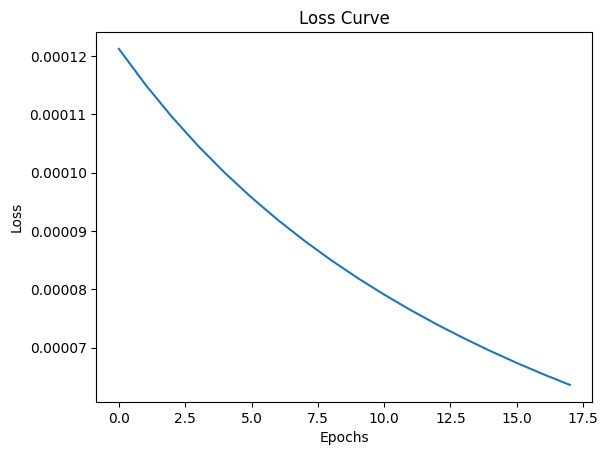

In [126]:
plt.plot(errorlist)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()